In [111]:
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, inv
import numpy as np

In [359]:
def bwgd_discard(y, A, eta, niter, threshold):
    d, n = A.shape  
    x = np.zeros((niter, d))  
    x[0] = np.random.randn(d)  

    # Descent
    for iter in range(1, niter):
        # Discard samples
        indices = np.abs(A.T @ x[iter - 1]) >= threshold        
        A_filtered = A.T[indices].T.copy()
        y_filtered = y[indices].copy()

        # Covariance matrix transform
        C = A_filtered @ A_filtered.T / n
        C_sqrt = sqrtm(C)
        C_inv = np.real(inv(C_sqrt))
        A_tilde = C_inv @ A_filtered 
        x_tilde = C_sqrt @ x[iter - 1]

        # Descent
        sum_gradient = A_tilde @ (np.sqrt(y_filtered) * (A_tilde.T @ x_tilde) / np.abs(A_tilde.T @ x_tilde))
        x_tilde = (1 - eta) * x_tilde + (eta / n) * sum_gradient

        x[iter] = C_inv @ x_tilde
        
    return x

C:\Users\gabreu\AppData\Local\Temp\ipykernel_12972\1127232305.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  x[iter] = C_inv @ x_tilde


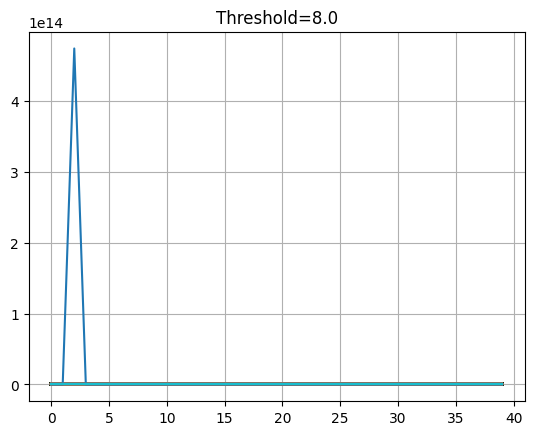

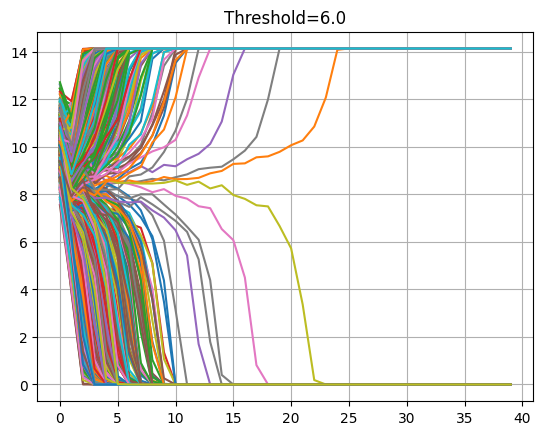

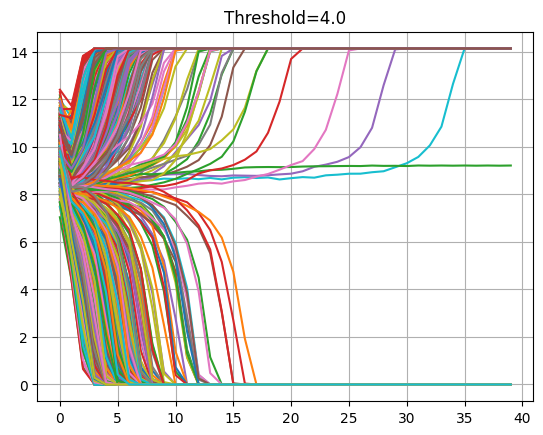

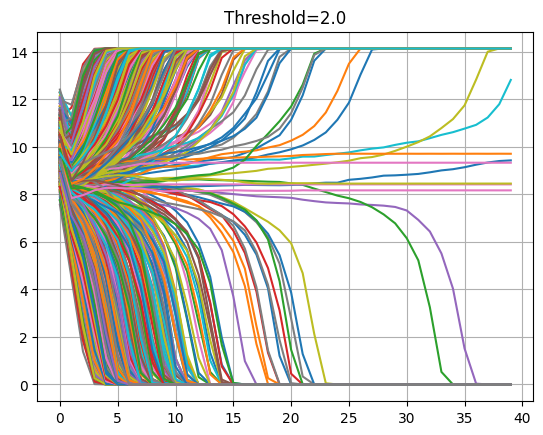

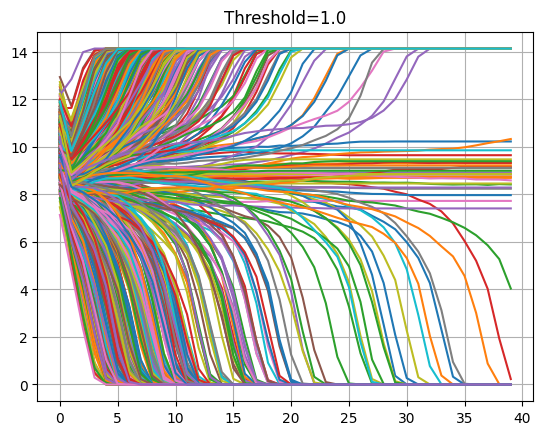

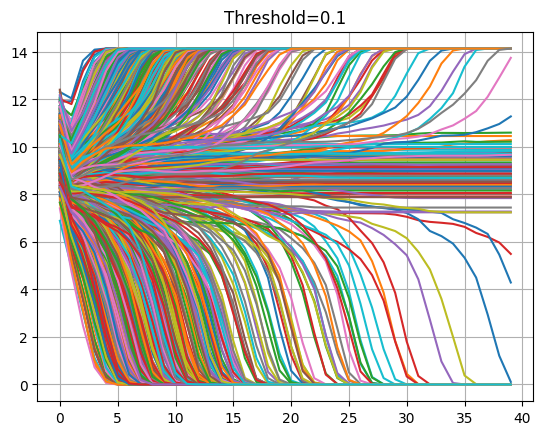

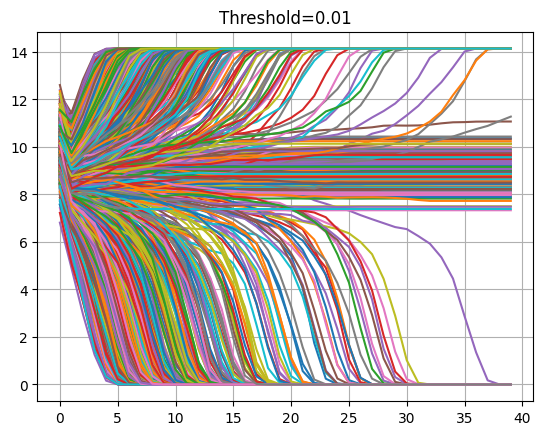

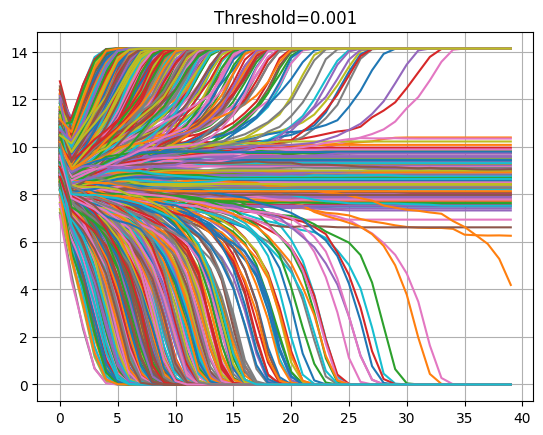

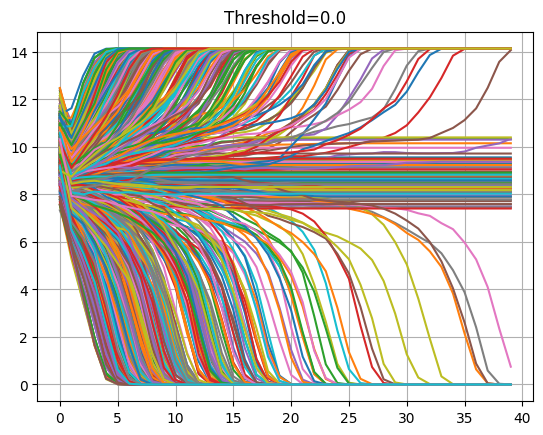

In [360]:
n = 1000
d = 50
errors = []
thresholds =  np.array([8, 6, 4, 2, 1e+00, 1e-01, 1e-02, 1e-03, 0])

for threshold in thresholds:
    threshold_error = []
    for j in range(1, 1001):  
        # Generate vectors
        x = np.ones(d)
        A = np.random.randn(d, n)
        y = np.square(A.T @ x)
        
        # Run the algorithm
        x_hat = bwgd_discard(y, A, 1, 40, threshold)

        error = np.linalg.norm(x_hat - x, axis=1)
        threshold_error.append(error)
        
        # Plot results
        plt.plot(error)

    errors.append(threshold_error)

    plt.title(f'Threshold={threshold}')
    plt.grid(True)
    plt.show()

In [361]:
for i in range(len(errors)):
    zero = 0
    for error in errors[i]:
        zero += error[-1] < 1e-13
    print(i, "\t",zero)

0 	 457
1 	 476
2 	 499
3 	 495
4 	 458
5 	 452
6 	 449
7 	 438
8 	 448
